In [1]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import scipy

In [2]:
filepath = r"C:\Users\melan\DESU_DATA_2026\ProjetNR\data2026.xlsx"
raw_df  = pd.read_excel(filepath, engine="openpyxl", sheet_name='Total2', header=0, na_values=['na', 'NaN', 'NA', 'N/A', 'n/a'])
raw_df.head()

,Patient,Hipp,P300,P600,LNC,N400,LRC,IQ,VCI,PRI,WMI,SPI,VBL,VSL,VBD,VSD,OB,ON
0,2 D,NI,-68.8,82.60,-54.1,NaN,NaN,96.0,98.0,100.0,91.0,94.0,105.0,123.0,101.0,115.0,98%,80/77
1,3 G,NI,-44.7,80.00,-46.9,0.0,4.69,122.0,116.0,124.0,120.0,105.0,105.0,103.0,104.0,103.0,NaN,NaN
2,4 D,NI,-108.1,96.40,-26.6,-50.7,-0.55,86.0,82.0,94.0,86.0,100.0,79.0,91.0,69.0,88.0,98%,62/70
3,6 D,NI,-35.3,0.00,0.0,23.7,-0.30,67.0,71.0,86.0,68.0,64.0,102.0,85.0,104.0,85.0,88%,53/69
4,6 G,NI,-38.7,42.14,0.0,NaN,NaN,67.0,71.0,86.0,68.0,64.0,102.0,85.0,104.0,85.0,88%,53/69


## Nettoyage des données

In [3]:
#Nettoyage minimal des données
percent_missing = raw_df.isnull().sum() * 100 / len(raw_df)
percent_missing.sort_values(ascending=False,inplace=True)
percent_missing

ON         61.538462
OB         60.000000
N400       35.384615
LRC        35.384615
IQ          9.230769
VSL         6.153846
VBD         6.153846
VSD         6.153846
VBL         6.153846
P300        4.615385
P600        4.615385
LNC         4.615385
PRI         3.076923
VCI         3.076923
WMI         3.076923
SPI         3.076923
Hipp        1.538462
Patient     0.000000
dtype: float64

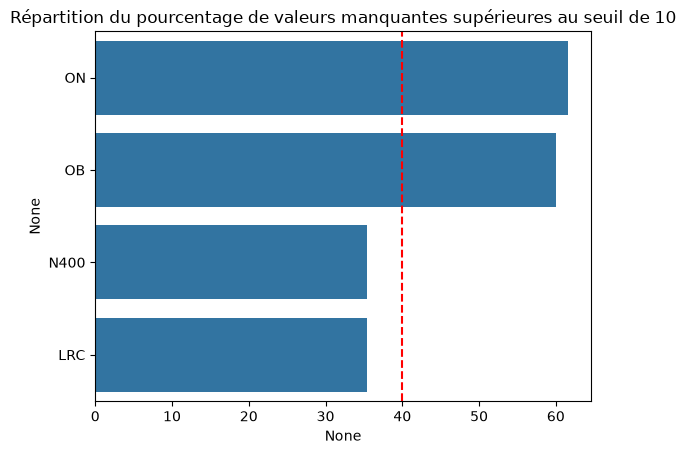

In [4]:
threshold_view = 10

filtered = percent_missing[percent_missing.values > threshold_view]
ax = sns.barplot(x = filtered, y = filtered.index, orient='h') 
ax.set_title(f"Répartition du pourcentage de valeurs manquantes supérieures au seuil de {threshold_view}");

threshold = 40

ax.axvline(x=threshold, color='r', linestyle='--', label=f"Seuil de {threshold}")

In [5]:
columns_to_drop = percent_missing[
    percent_missing.values > threshold].index
columns_to_drop

Index(['ON', 'OB'], dtype='str')

In [6]:
raw_df.drop(columns=columns_to_drop, inplace=True, errors="ignore")
raw_df.shape

(65, 16)

## Imputation valeurs manquantes

In [7]:
numeric_features = raw_df.select_dtypes(include=['float','int'])
numeric_features.shape

(65, 14)

In [17]:
from sklearn.impute import KNNImputer
imputation = KNNImputer(missing_values=np.nan)
imputed = imputation.fit_transform(numeric_features)
imputed = pd.DataFrame(imputed, columns=numeric_features.columns, index=raw_df.index)
imputed.shape

(65, 14)

In [18]:
raw_df.loc[:,numeric_features.columns] = imputed
numeric_features.columns

Index(['P300', 'P600', 'LNC', 'N400', 'LRC', 'IQ', 'VCI', 'PRI', 'WMI', 'SPI',
       'VBL', 'VSL', 'VBD', 'VSD'],
      dtype='str')

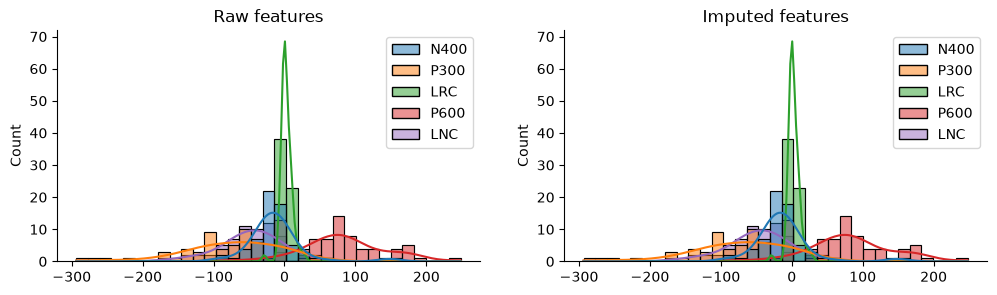

In [26]:
def compare_dist(features):
    fig, axes = plt.subplots(1,2,figsize=(12,3))
    ax=axes[0]
    sns.histplot(raw_df.loc[:,features],kde=True, ax=ax)
    ax.set_title(f"Raw features")
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    
    ax=axes[1]
    sns.histplot(imputed.loc[:,features],kde=True, ax=ax)
    ax.set_title(f"Imputed features")
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
compare_dist(["N400", "P300", "LRC", "P600", "LNC"])

## Outliers

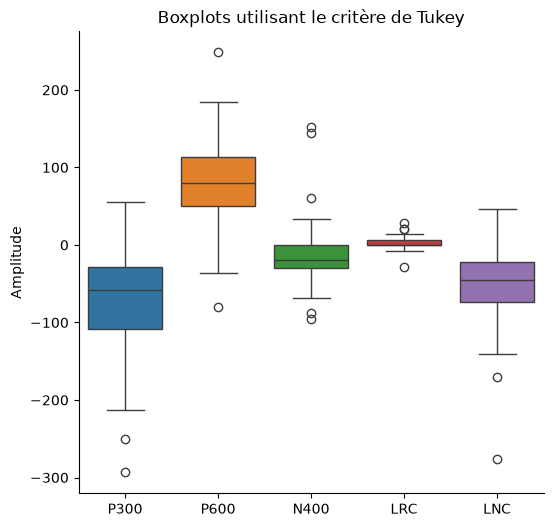

In [30]:
import seaborn as sns
fig, ax = plt.subplots(figsize=(6,6))
sns.boxplot(data=raw_df.loc[:,["P300","P600", "N400", "LRC", "LNC"]], ax=ax)
ax.set_ylabel("Amplitude")
ax.set_title("Boxplots utilisant le critère de Tukey")
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

In [31]:
imputed.head(5)

,P300,P600,LNC,N400,LRC,IQ,VCI,PRI,WMI,SPI,VBL,VSL,VBD,VSD
0,-68.8,82.60,-54.1,-49.182,9.22,96.0,98.0,100.0,91.0,94.0,105.0,123.0,101.0,115.0
1,-44.7,80.00,-46.9,0.000,4.69,122.0,116.0,124.0,120.0,105.0,105.0,103.0,104.0,103.0
2,-108.1,96.40,-26.6,-50.700,-0.55,86.0,82.0,94.0,86.0,100.0,79.0,91.0,69.0,88.0
3,-35.3,0.00,0.0,23.700,-0.30,67.0,71.0,86.0,68.0,64.0,102.0,85.0,104.0,85.0
4,-38.7,42.14,0.0,8.880,-5.80,67.0,71.0,86.0,68.0,64.0,102.0,85.0,104.0,85.0


# Scaling

## Standardisation

Text(0.5, 1.0, 'Scaled data')

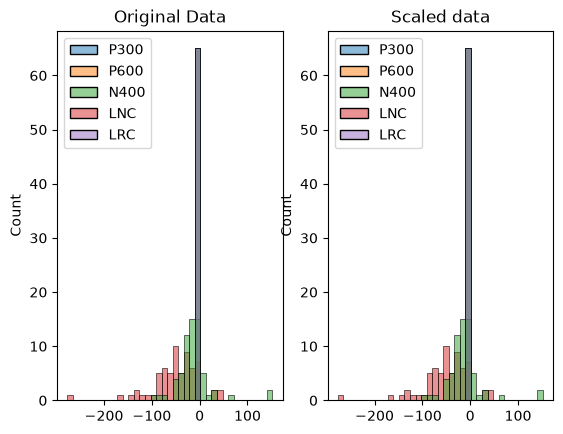

In [42]:
import numpy as np
import seaborn as sns
from mlxtend.preprocessing import minmax_scaling
import matplotlib.pyplot as plt

# mix-max scale the data between 0 and 1
scaled_data = minmax_scaling(imputed, columns=["P300", "P600", "N400", "LNC", "LRC"])

# plot both together to compare
fig, ax = plt.subplots(1,2)
sns.histplot(scaled_data, ax=ax[0])
ax[0].set_title("Original Data")
sns.histplot(scaled_data, ax=ax[1])
ax[1].set_title("Scaled data")